In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv('./data/online_retail.csv', parse_dates=['InvoiceDate'])

In [3]:
data = df.copy()   # 永远保留一份原始数据

In [4]:
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


### 1. 数据清洗

In [5]:
temp = df[(df['StockCode'].astype(str).str[0].str.isdigit()) & (df['Invoice'].astype(str).str[0].str.isdigit())]   # 首字符是数字

In [6]:
data_sales = temp[(temp['Quantity'] > 0) & (temp['Price'] > 0)]   # 剔除customer id缺失的数据

In [7]:
data_customer = data_sales.dropna(subset=['Customer ID'])   # 剔除customer id缺失的数据

In [36]:
data_sales.to_csv('./data/cleaned_sales.csv', index=False)

In [37]:
data_customer.to_csv('./data/cleaned_customer.csv', index=False)

In [8]:
data_sales.shape

(1036877, 8)

In [9]:
data_customer.shape

(802632, 8)

In [10]:
data_sales.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.036877e+06,1036877,1.036877e+06,802632.000000
mean,1.099685e+01,2011-01-03 18:01:53.222899,3.339188e+00,15338.166822
min,1.000000e+00,2009-12-01 07:45:00,3.000000e-02,12346.000000
25%,1.000000e+00,2010-07-12 10:54:00,1.250000e+00,13988.000000
50%,3.000000e+00,2010-12-07 15:33:00,2.100000e+00,15276.000000
75%,1.100000e+01,2011-07-24 13:17:00,4.130000e+00,16809.000000
max,8.099500e+04,2011-12-09 12:50:00,1.157150e+03,18287.000000
std,1.267840e+02,NaN,4.735151e+00,1693.906223


In [11]:
data_customer.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,802632.000000,802632,802632.000000,802632.000000
mean,13.319211,2011-01-02 09:25:22.566755,2.930763,15338.166822
min,1.000000,2009-12-01 07:45:00,0.030000,12346.000000
25%,2.000000,2010-07-07 12:02:00,1.250000,13988.000000
50%,5.000000,2010-12-03 14:54:00,1.950000,15276.000000
75%,12.000000,2011-07-28 13:02:00,3.750000,16809.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,143.868968,NaN,4.275915,1693.906223


In [12]:
data_sales['GMV'] = data_sales['Quantity'] * data_sales['Price']
data_customer['GMV'] = data_customer['Quantity'] * data_customer['Price']

In [13]:
sales_gmv = data_sales.resample('ME', on='InvoiceDate')['GMV'].sum()
sales_gmv.index = sales_gmv.index.to_period('M')

In [14]:
customer_gmv = data_customer.resample('ME', on='InvoiceDate')['GMV'].sum()
customer_gmv.index = customer_gmv.index.to_period('M')

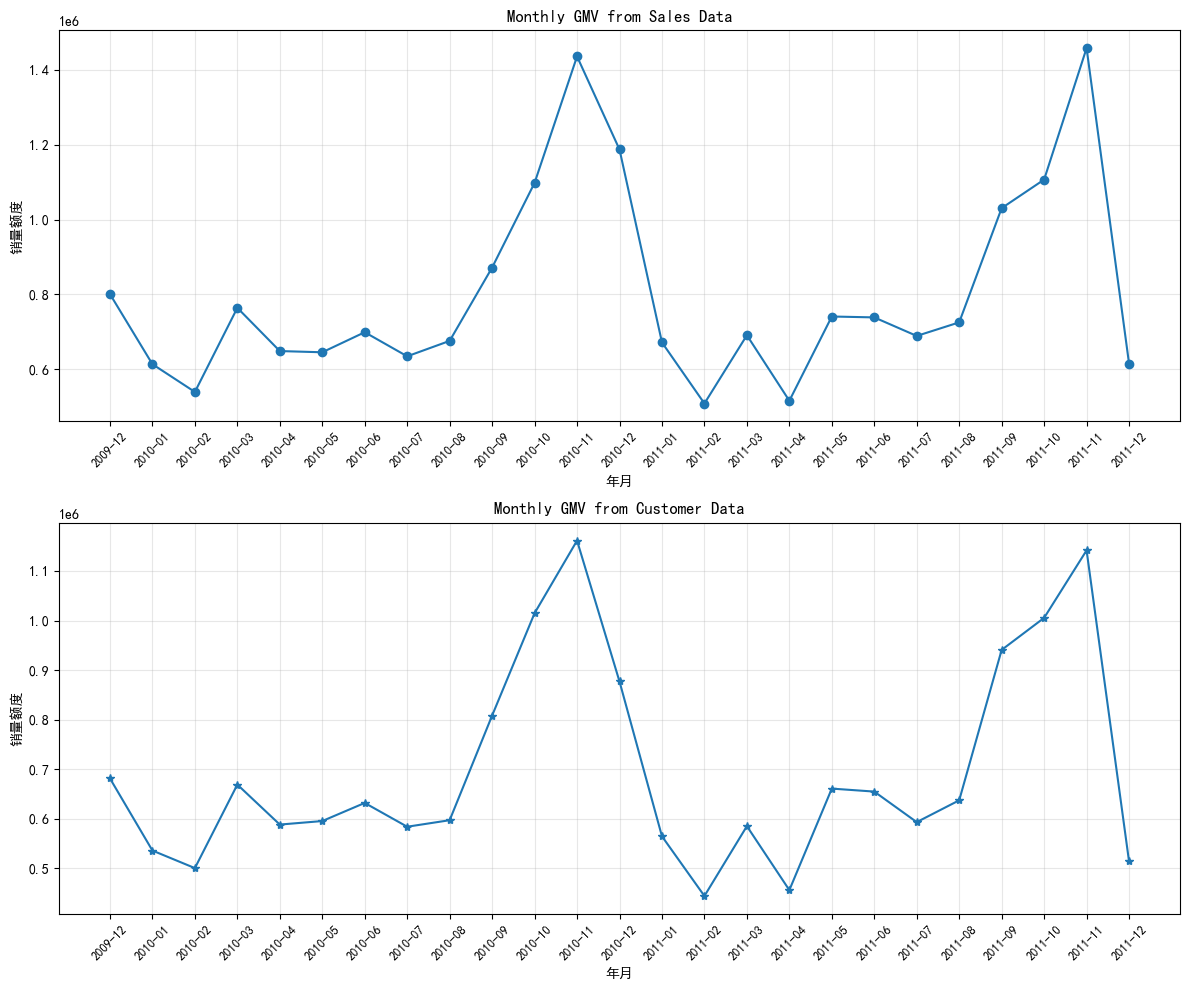

In [15]:
plt.rcParams['font.family'] = 'SimHei'  # 替换为你选择的字体
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
ax1.plot(sales_gmv.index.astype(str), sales_gmv.values, marker='o')# 加个圆点，每个月看得更清楚
ax2.plot(customer_gmv.index.astype(str), customer_gmv.values, marker='*')# 加个圆点，每个月看得更清楚
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax1.set_title('Monthly GMV from Sales Data')
ax2.set_title('Monthly GMV from Customer Data')
ax1.set_xlabel('年月')
ax2.set_xlabel('年月')
ax1.set_ylabel('销量额度')
ax2.set_ylabel('销量额度')
ax1.grid(alpha=0.3)   # 加网格线，读数更方便
ax2.grid(alpha=0.3)   # 加网格线，读数更方便
fig1.tight_layout()
plt.show()

In [16]:
#客户数
customer_month = data_customer.resample('ME', on='InvoiceDate')['Customer ID'].nunique()
customer_month.index = customer_month.index.to_period('M')
customer_month 

InvoiceDate
2009-12     951
2010-01     701
2010-02     771
2010-03    1051
2010-04     939
2010-05     965
2010-06    1034
2010-07     924
2010-08     910
2010-09    1136
2010-10    1492
2010-11    1606
2010-12     884
2011-01     739
2011-02     757
2011-03     973
2011-04     853
2011-05    1054
2011-06     990
2011-07     946
2011-08     933
2011-09    1259
2011-10    1361
2011-11    1660
2011-12     614
Freq: M, Name: Customer ID, dtype: int64

In [17]:
#订单数
order_quantity = data_sales.resample('ME', on='InvoiceDate')['Invoice'].nunique()
order_quantity.index = order_quantity.index.to_period('M')
order_quantity 

InvoiceDate
2009-12    1666
2010-01    1049
2010-02    1189
2010-03    1647
2010-04    1435
2010-05    1484
2010-06    1612
2010-07    1507
2010-08    1402
2010-09    1789
2010-10    2244
2010-11    2719
2010-12    1550
2011-01    1081
2011-02    1093
2011-03    1440
2011-04    1235
2011-05    1668
2011-06    1525
2011-07    1452
2011-08    1339
2011-09    1818
2011-10    2005
2011-11    2751
2011-12     816
Freq: M, Name: Invoice, dtype: int64

In [18]:
order_quantity_cus = data_customer.resample('ME', on='InvoiceDate')['Invoice'].nunique()
order_quantity_cus.index = order_quantity_cus.index.to_period('M')
order_quantity_cus

InvoiceDate
2009-12    1497
2010-01     959
2010-02    1093
2010-03    1509
2010-04    1315
2010-05    1365
2010-06    1479
2010-07    1362
2010-08    1276
2010-09    1659
2010-10    2108
2010-11    2570
2010-12    1394
2011-01     983
2011-02     992
2011-03    1312
2011-04    1139
2011-05    1544
2011-06    1390
2011-07    1321
2011-08    1267
2011-09    1739
2011-10    1903
2011-11    2642
2011-12     776
Freq: M, Name: Invoice, dtype: int64

In [19]:
#件数
items_quantity = data_sales.resample('ME', on='InvoiceDate')['Quantity'].sum()
items_quantity.index = items_quantity.index.to_period('M')
items_quantity

InvoiceDate
2009-12    426709
2010-01    391261
2010-02    382521
2010-03    526349
2010-04    367549
2010-05    396773
2010-06    408013
2010-07    338573
2010-08    472970
2010-09    584850
2010-10    621592
2010-11    727514
2010-12    539456
2011-01    387422
2011-02    283243
2011-03    377071
2011-04    308509
2011-05    395378
2011-06    388826
2011-07    401329
2011-08    421439
2011-09    569945
2011-10    621728
2011-11    750081
2011-12    313282
Freq: M, Name: Quantity, dtype: int64

In [20]:
#客单价
customer_price = customer_gmv.values / order_quantity_cus.values
customer_price_series = pd.Series(customer_price, index=customer_gmv.index)
customer_price_series

InvoiceDate
2009-12    454.954055
2010-01    558.111960
2010-02    457.227521
2010-03    443.059768
2010-04    446.961042
2010-05    435.814315
2010-06    426.980967
2010-07    428.332254
2010-08    467.538574
2010-09    487.127824
2010-10    481.558226
2010-11    452.083428
2010-12    629.135201
2011-01    573.780916
2011-02    446.921391
2011-03    445.550953
2011-04    399.707559
2011-05    427.773251
2011-06    470.814791
2011-07    448.699394
2011-08    502.610292
2011-09    541.058545
2011-10    528.451340
2011-11    432.303471
2011-12    661.379420
Freq: M, dtype: float64

In [21]:
#件均价
item_price = sales_gmv.values / items_quantity.values
item_price_series = pd.Series(item_price, index=sales_gmv.index)
item_price_series

InvoiceDate
2009-12    1.877016
2010-01    1.568837
2010-02    1.410978
2010-03    1.452066
2010-04    1.765441
2010-05    1.627197
2010-06    1.713603
2010-07    1.875183
2010-08    1.429393
2010-09    1.490741
2010-10    1.766334
2010-11    1.973203
2010-12    2.200506
2011-01    1.734323
2011-02    1.796584
2011-03    1.832898
2011-04    1.673192
2011-05    1.874545
2011-06    1.899955
2011-07    1.717518
2011-08    1.721468
2011-09    1.808014
2011-10    1.779985
2011-11    1.943446
2011-12    1.964652
Freq: M, dtype: float64

In [23]:
#top20国家gmv排行
top_countries = data_sales.groupby('Country')['GMV'].sum().sort_values(ascending=False).head(20)
top_countries

Country
United Kingdom     17232715.69
EIRE                 628928.63
Netherlands          549952.66
Germany              388829.75
France               316948.80
Australia            168484.66
Spain                 98612.79
Switzerland           94270.29
Sweden                86353.04
Denmark               68560.19
Belgium               57322.77
Portugal              48819.39
Japan                 47138.39
Channel Islands       44353.76
Norway                42362.48
Italy                 29323.75
Finland               25180.10
Cyprus                24614.44
Austria               20297.01
Greece                18711.19
Name: GMV, dtype: float64

In [24]:
#top20商品gmv排行
top_items = data_sales.groupby('StockCode')['GMV'].sum()
top_items = pd.DataFrame(top_items)
top_items['description'] = data_sales.groupby('StockCode')['Description'].first()
top_items = top_items.sort_values(by='GMV', ascending=False).head(20)
top_items

,GMV,description
StockCode,,
22423,344563.25,REGENCY CAKESTAND 3 TIER
85123A,263109.67,WHITE HANGING HEART T-LIGHT HOLDER
85099B,183454.83,JUMBO BAG RED WHITE SPOTTY
23843,168469.60,"PAPER CRAFT , LITTLE BIRDIE"
47566,149187.05,PARTY BUNTING
84879,132187.92,ASSORTED COLOUR BIRD ORNAMENT
22086,123141.54,PAPER CHAIN KIT 50'S CHRISTMAS
79321,85489.91,CHILLI LIGHTS
23166,81700.92,MEDIUM CERAMIC TOP STORAGE JAR


In [25]:
#复购率
print(f"复购率：{(data_customer.groupby('Customer ID')['Invoice'].nunique() > 1).mean()*100:.2f}%")

复购率：72.35%


In [26]:
#消费金额分布
per_customer = data_customer.groupby('Customer ID')['GMV'].sum()
per_customer = per_customer.sort_values(ascending=False).reset_index()
per_customer

,Customer ID,GMV
0,18102.0,608821.65
1,14646.0,526751.52
2,14156.0,303578.63
3,14911.0,276654.61
4,17450.0,246973.09
...,...,...
5847,15913.0,6.30
5848,14792.0,6.20
5849,16738.0,3.75
5850,13788.0,3.75


In [27]:
per_customer['累计GMV'] = per_customer['GMV'].cumsum()
per_customer['累计GMV占比'] = per_customer['累计GMV'] / per_customer['GMV'].sum()
per_customer['累计客户占比'] = (per_customer.index + 1) / len(per_customer)
per_customer[per_customer['累计GMV占比'] >= 0.8].head(1)['累计客户占比']

1351    0.231032
Name: 累计客户占比, dtype: float64

In [28]:
# 找到累计 GMV 占比首次超过 80% 的那一行
threshold = per_customer[per_customer['累计GMV占比'] >= 0.8].iloc[0]
print(f"贡献 80% GMV 的客户占比: {threshold['累计客户占比']*100:.1f}%")
print(f"也就是说,前 {threshold.name+1} 个客户贡献了 80% 的销售")

贡献 80% GMV 的客户占比: 23.1%
也就是说,前 1352 个客户贡献了 80% 的销售


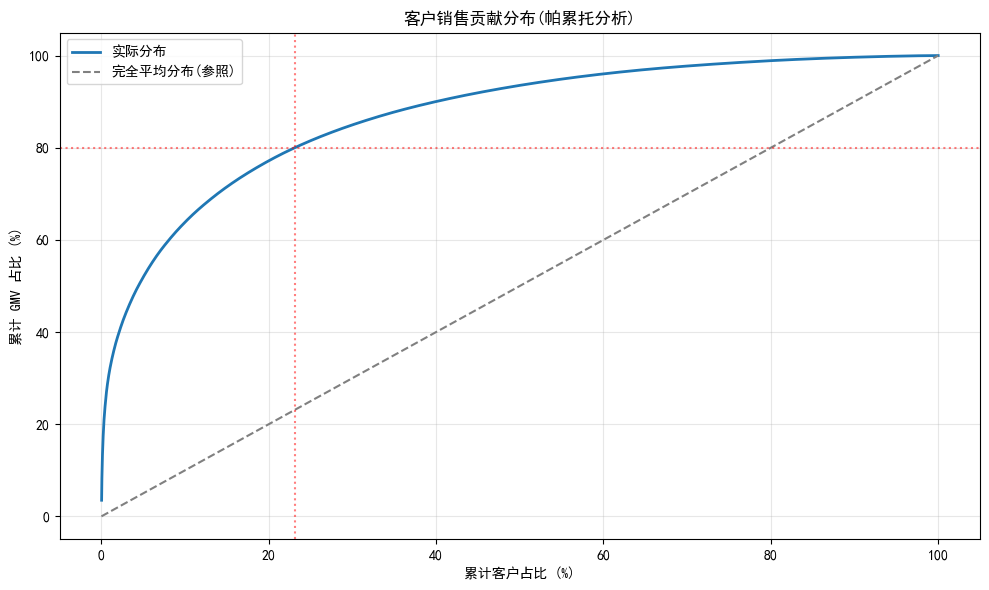

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(per_customer['累计客户占比'] * 100, 
         per_customer['累计GMV占比'] * 100, 
         linewidth=2, label='实际分布')

# 画一条对角线作为"完全平均分布"参照
plt.plot([0, 100], [0, 100], '--', color='gray', label='完全平均分布(参照)')

# 标出 80% 的位置
plt.axhline(y=80, color='red', linestyle=':', alpha=0.5)
plt.axvline(x=threshold['累计客户占比']*100, color='red', linestyle=':', alpha=0.5)

plt.xlabel('累计客户占比 (%)')
plt.ylabel('累计 GMV 占比 (%)')
plt.title('客户销售贡献分布(帕累托分析)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# 每个客户的不同订单数
orders_per_customer = data_customer.groupby('Customer ID')['Invoice'].nunique()
# 复购率 = 订单数 ≥ 2 的客户占比
repurchase_rate = (orders_per_customer >= 2).mean() * 100
print(f"复购率: {repurchase_rate:.2f}%")
print(f"总客户数: {len(orders_per_customer)}")
print(f"复购客户数: {(orders_per_customer >= 2).sum()}")
print(f"一次性客户: {(orders_per_customer == 1).sum()}")

复购率: 72.35%
总客户数: 5852
复购客户数: 4234
一次性客户: 1618


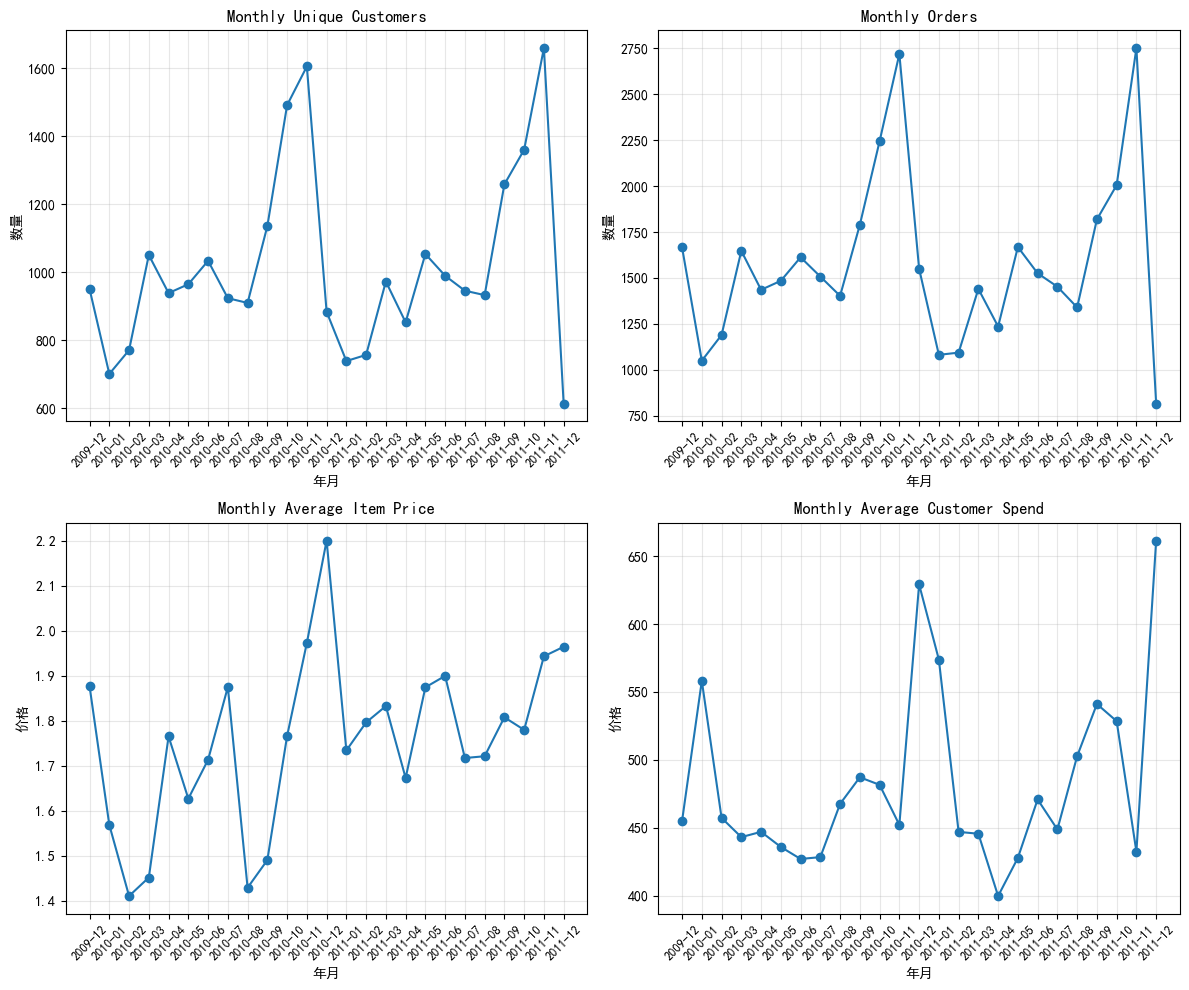

In [31]:
fig2, ax = plt.subplots(2, 2, figsize=(12, 10))

# 数据 + 标题 + 标签 打包成列表
plots = [
    (ax[0, 0], customer_month, 'Monthly Unique Customers', '数量'),
    (ax[0, 1], order_quantity, 'Monthly Orders', '数量'),
    (ax[1, 0], item_price_series, 'Monthly Average Item Price', '价格'),
    (ax[1, 1], customer_price_series, 'Monthly Average Customer Spend', '价格'),
]

# 循环画图
for axis, data, title, ylabel in plots:
    axis.plot(data.index.astype(str), data.values, marker='o')
    axis.set_title(title)
    axis.set_xlabel('年月')
    axis.set_ylabel(ylabel)
    axis.tick_params(axis='x', rotation=45, labelsize=9)
    axis.grid(alpha=0.3)

fig2.tight_layout()
plt.show()

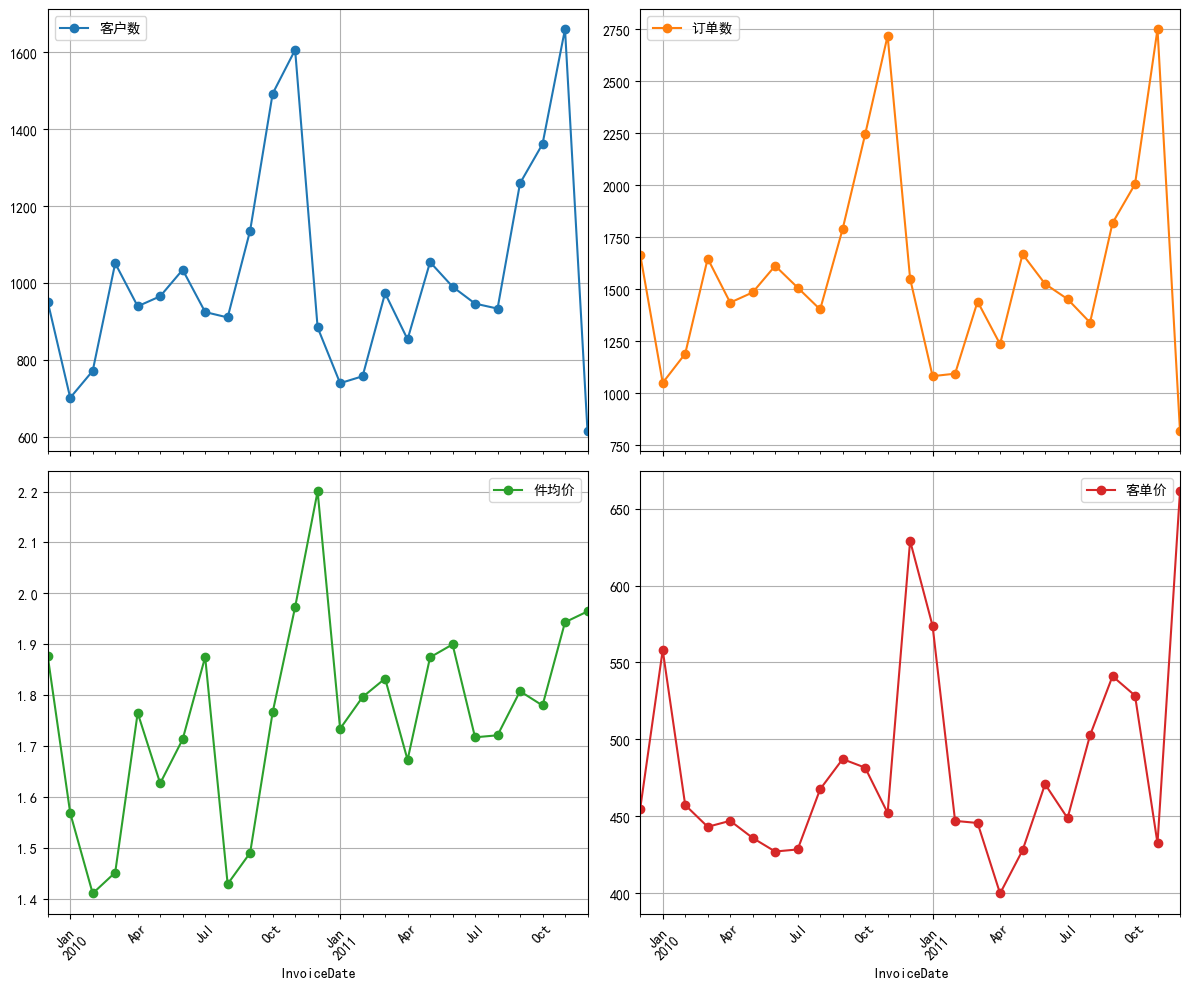

In [32]:
combined = pd.DataFrame({
    '客户数': customer_month,
    '订单数': order_quantity,
    '件均价': item_price_series,
    '客单价': customer_price_series
})

axes = combined.plot(subplots=True, layout=(2,2), figsize=(12, 10), 
                     marker='o', grid=True, rot=45)
plt.tight_layout()
plt.show()

In [40]:
monthly = data_sales.groupby(data_sales['InvoiceDate'].dt.to_period('M')).agg(
    GMV=('GMV', 'sum'),
    订单数=('Invoice', 'nunique'),
    件数=('Quantity', 'sum'),
    客户数=('Customer ID', 'nunique')   # NaN 会自动忽略
)

# 直接在结果上算衍生指标
monthly['客单价'] = monthly['GMV'] / monthly['订单数']
monthly['件均价'] = monthly['GMV'] / monthly['件数']
monthly['人均消费'] = monthly['GMV'] / monthly['客户数']

In [39]:
monthly

,GMV,订单数,件数,客户数,客单价,件均价,人均消费
InvoiceDate,,,,,,,
2009-12,800939.83,1666,426709,951,480.756200,1.877016,842.208023
2010-01,613824.59,1049,391261,701,585.152135,1.568837,875.641355
2010-02,539728.55,1189,382521,771,453.934861,1.410978,700.037030
2010-03,764293.49,1647,526349,1051,464.051906,1.452066,727.205985
2010-04,648886.07,1435,367549,939,452.185415,1.765441,691.039478
2010-05,645627.64,1484,396773,965,435.059057,1.627197,669.044187
2010-06,699172.30,1612,408013,1034,433.729715,1.713603,676.182108
2010-07,634886.18,1507,338573,924,421.291427,1.875183,687.106255
2010-08,676059.87,1402,472970,910,482.211034,1.429393,742.922934
